<table width=100%>
<tr>
    <td><h1 style="text-align: left; font-size:250%;">
        Wisconsin Breast Cancer 
    </h1></td>
    <td width="35%">
    <div style="text-align: right">
    <b>Breast Cancer  Classifier </b> <br>
    <b><br>
    Antonio Astorino <br>
    <a href="mailto:antonio.as@hotmail.it">antonio.as@hotmail.it</a><br>
    </div>
    </td>
    </td>
</tr>
</table>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, recall_score, RocCurveDisplay, make_scorer, confusion_matrix

np.random.seed(0)

# Main goal

Predict predict benign or malignant breast cancer based on a set of cytology features.

In [2]:
#Import the dataset
df_canc = pd.read_csv("/Users/hastors/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/2 Semester/Machine Learning/Homework 2/BreastCancer/breast_cancer_wisconsin.data", na_values = '?')
# I set the na_values because I already know from the info file that the missing values are '?' 

# Data 

In [3]:
df_canc.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   1000025  698 non-null    int64  
 1   5        698 non-null    int64  
 2   1        698 non-null    int64  
 3   1.1      698 non-null    int64  
 4   1.2      698 non-null    int64  
 5   2        698 non-null    int64  
 6   1.3      682 non-null    float64
 7   3        698 non-null    int64  
 8   1.4      698 non-null    int64  
 9   1.5      698 non-null    int64  
 10  2.1      698 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.1 KB


In [4]:
df_canc.shape

(698, 11)

The dataset consists in 11 entries, 10 attributes and the class (2 for benign, 4 for malignant).

In [5]:
#I rename the columns as named in the info file
column_names=['Code_number','Clump_Thickness', 'Uniformity_of_Cell_Size', 'Uniformity_of_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

In [6]:
# Naming columns
df_canc = pd.read_csv("/Users/hastors/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/2 Semester/Machine Learning/Homework 2/BreastCancer/breast_cancer_wisconsin.data", names=column_names, na_values = '?')

In [7]:
# Check if there are and how many samples with missing values there are
df_canc.isna().sum()

Code_number                     0
Clump_Thickness                 0
Uniformity_of_Cell_Size         0
Uniformity_of_Cell_Shape        0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [8]:
#Only the 'Bare Nuclei' column contains missing values. We can safetly remove these missing values since they're not so many. 
#In fact they are only 16. We can also replace with the median values of the column.
df_canc.dropna(inplace = True)

In [9]:
#Drop the code number column. Don't necessary
df_canc=df_canc.drop('Code_number', axis=1)

In [10]:
#Setting new values for Class 1 malignant 0 benign
df_canc['Class']=df_canc['Class'].replace({4: 1, 2:0})

## Explore the data

<AxesSubplot:>

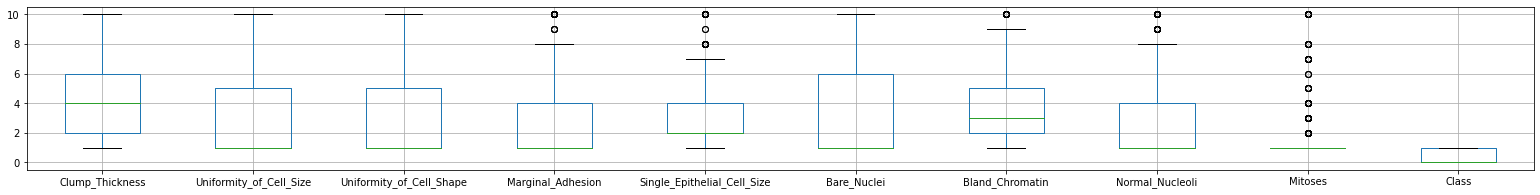

In [11]:
df_canc.boxplot(figsize=(27,3))

<AxesSubplot:>

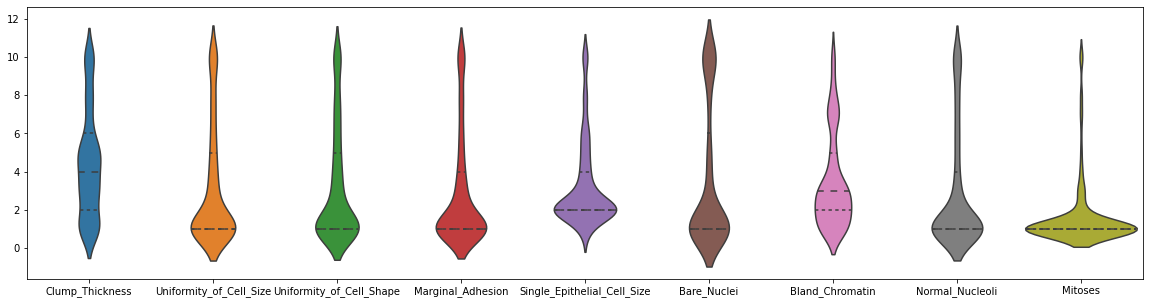

In [12]:
f, ax = plt.subplots(figsize=(20, 5))
sns.violinplot(data=df_canc.drop(["Class"],axis = 1), width = 0.9, inner = 'quartile')

The boxplots suggest that thay may be outliers. We could compute z-score for every attribute and remove the ones with extremely high or low z-value but since they are not so many outliers i choose to not remove them.

We can also notice that the observations seem to be centered (mean) between 0 and 2, maybe because of the sensitivity of the microscope. 

array([[<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>],
       [<AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel='Density'>,
        <AxesSubplot:ylabel='Density'>, <AxesSubplot:ylabel=

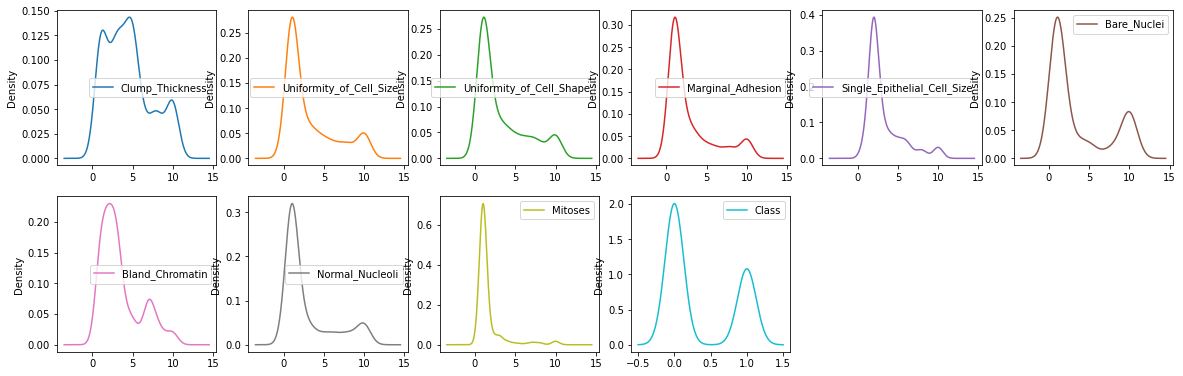

In [13]:
#check the approximate distributions
df_canc.plot(kind='density', subplots=True, layout=(6,6), figsize=(20,20), sharex=False, sharey=False)

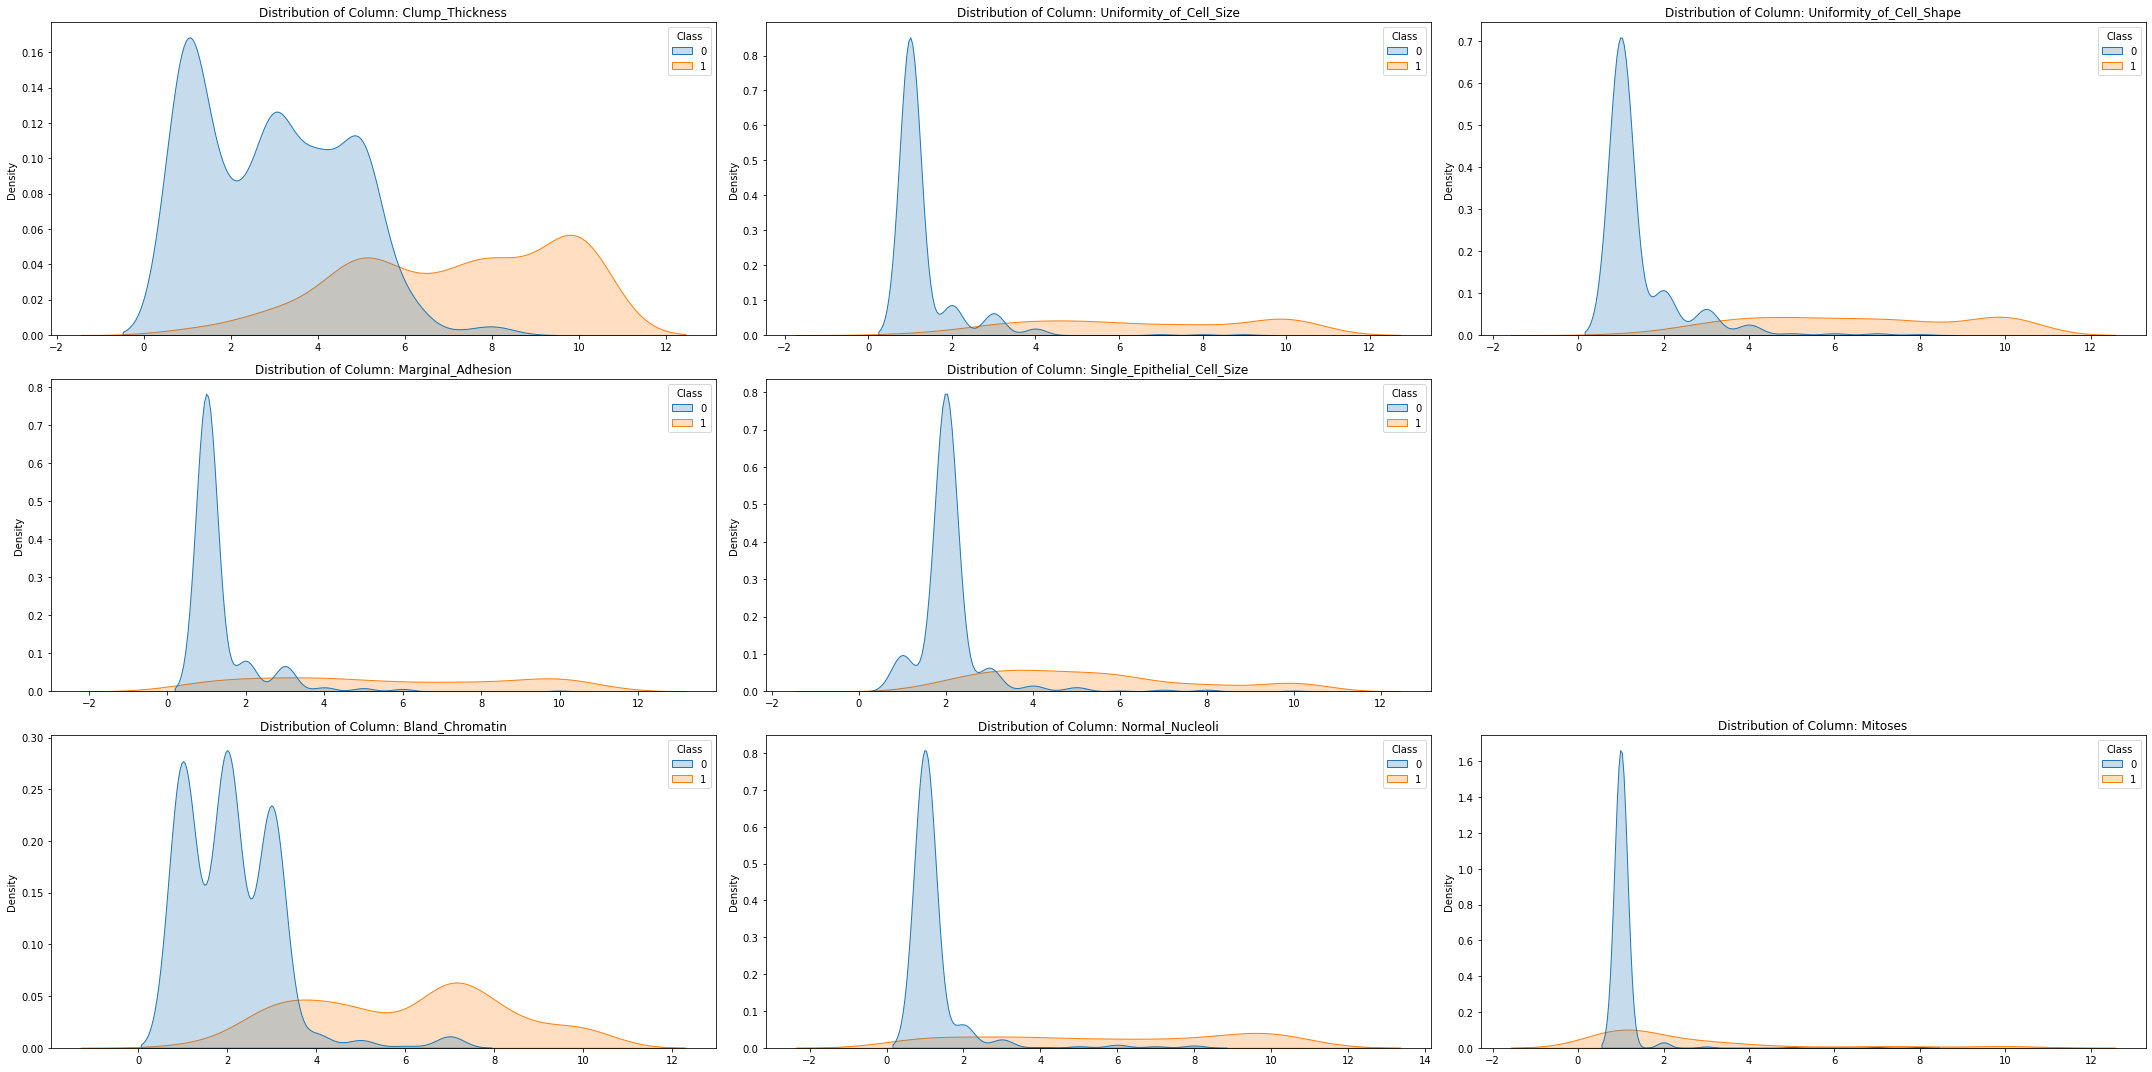

In [14]:
#Divided by class
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(30, 15), sharex=False, sharey=False)
axes = axes.ravel()
cols = df_canc.columns[:-1]  

for col, ax in zip(cols, axes):
    data = df_canc[[col, 'Class']]  # select the data
    sns.kdeplot(data=data, x=col, hue='Class', shade=True, ax=ax)
    ax.set(title=f'Distribution of Column: {col}', xlabel=None)
    
fig.delaxes(axes[5])
fig.tight_layout()
plt.show()

The data is quite unbalanced. The plots suggest that higher values can higher the chances of the expression of malignant cancer (I know that, for some tissue, there is a biological evidence right like this).

In [15]:
#Correlation matrix
corrMatrix = df_canc.corr(method='spearman')
corrMatrix

,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
Clump_Thickness,1.000000,0.663684,0.666652,0.543815,0.586755,0.590770,0.533848,0.566398,0.421208,0.683080
Uniformity_of_Cell_Size,0.663684,1.000000,0.894978,0.745475,0.792814,0.769543,0.720595,0.752510,0.512688,0.860299
Uniformity_of_Cell_Shape,0.666652,0.894978,1.000000,0.718722,0.765073,0.752950,0.694888,0.724410,0.478400,0.843245
Marginal_Adhesion,0.543815,0.745475,0.718722,1.000000,0.665190,0.696792,0.628738,0.636409,0.447254,0.737737
Single_Epithelial_Cell_Size,0.586755,0.792814,0.765073,0.665190,1.000000,0.694579,0.645090,0.710628,0.483210,0.775066
Bare_Nuclei,0.590770,0.769543,0.752950,0.696792,0.694579,1.000000,0.678963,0.659762,0.474316,0.835444
Bland_Chromatin,0.533848,0.720595,0.694888,0.628738,0.645090,0.678963,1.000000,0.662096,0.390600,0.744571
Normal_Nucleoli,0.566398,0.752510,0.724410,0.636409,0.710628,0.659762,0.662096,1.000000,0.510210,0.748601
Mitoses,0.421208,0.512688,0.478400,0.447254,0.483210,0.474316,0.390600,0.510210,1.000000,0.527379
Class,0.683080,0.860299,0.843245,0.737737,0.775066,0.835444,0.744571,0.748601,0.527379,1.000000


<AxesSubplot:>

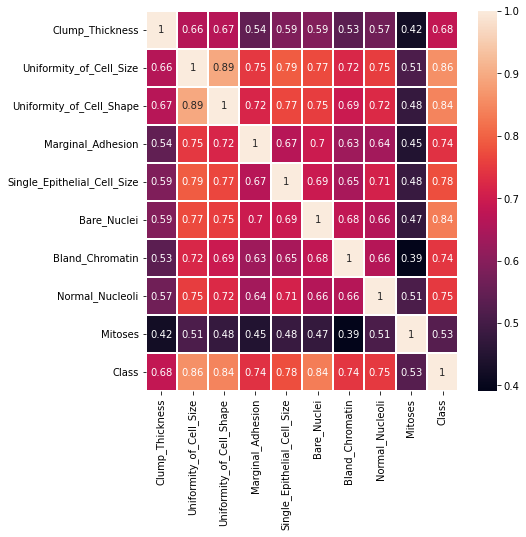

In [16]:
fig, ax = plt.subplots(figsize=(7,7 ))        
sns.heatmap(corrMatrix, annot=True, linewidths=.2, ax=ax)

Here we can highlight that the bigger the number on (almost all) features, the bigger the Class is. So in this case, the chance of being malignant is higher when all of the features have a high number.
<br>
Since they're all highly correlated, data suggest that there can be autocorrelation.

# Analysis

I will perform analysis on different models:
 <br>   **Logistic regression, LDA, QDA,KNN, SVM** <br>
I will also show the **Confusion Matrix** and **ROC curve** to see how the model prediction can change.

## Multiple Logistic Regression

In [17]:
split_seed = 42
split_test_size = 0.25 

# Train a logistic regressor that uses all features
X_full = df_canc.drop(['Class'], axis=1)
y = df_canc['Class']

X_full_train, X_full_test, y_train, y_test = train_test_split(X_full, y,
                                                    test_size=split_test_size,
                                                    random_state=split_seed)



In [18]:
model = LogisticRegression(solver='newton-cg', penalty='none') 
model.fit(X_full_train, y_train)

print("Train accuracy:", accuracy_score(y_train, model.predict(X_full_train)))
print("Train recall:", recall_score(y_train, model.predict(X_full_train)))
print("Test accuracy:", accuracy_score(y_test, model.predict(X_full_test)))
print("Test recall:", recall_score(y_test, model.predict(X_full_test)));


Train accuracy: 0.97265625
Train recall: 0.9649122807017544
Test accuracy: 0.9532163742690059
Test recall: 0.8970588235294118


After perform a train split test which puts 75% of data into training and 25% into test set we observe a test accuracy of 0.96, which is really good. <br>
To verify if the beta coefficients obtained are relevant, perform a **Z test**

In [19]:
#Z test implementation
from scipy.stats import norm, zscore


def z_test(X, y, model, names, alpha=None):
    n_samples, n_features = X.shape
    betas = np.concatenate([model.intercept_, model.coef_.reshape(-1)])
    
    # Compute the prediction
    pred = model.predict_proba(X) # [N, 2]
    y = y.reshape(-1)    
    X = np.concatenate([np.ones([X.shape[0], 1]), X], axis=-1)
    n_samples, n_features = X.shape
    
    V = np.diagflat(np.product(pred, axis=1))
    covLogit = np.linalg.inv(np.dot(np.dot(X.T, V), X))
    se_b = np.sqrt(np.diag(covLogit)) 
    
    z_stat_b = (betas-0)/se_b

    # Compute the p-value (two-sided test)
    p_values = np.array([2 * norm.sf(np.abs(z_stat)) for z_stat in z_stat_b])
    
    df = pd.DataFrame()
    df["Name"] = names
    df["Coefficients"] = betas
    df["Standard Errors"] = np.round(se_b, decimals=4)
    df["Z-stat"] = np.round(z_stat_b, decimals=1)
    df["p-value"] = p_values
    if alpha:
        rejectH0 = p_values < alpha
        df["reject H0"] = rejectH0    
    
    return df
#Perform the Z test on my model
X_full_feat = X_full_train.columns
z_test(X_full_train.to_numpy(), y_train.to_numpy(), model, ["Intercept", *X_full_feat], alpha=0.05)

,Name,Coefficients,Standard Errors,Z-stat,p-value,reject H0
0,Intercept,-10.063983,1.4076,-7.1,8.688774e-13,True
1,Clump_Thickness,0.487399,0.1573,3.1,1.949462e-03,True
2,Uniformity_of_Cell_Size,-0.069494,0.2454,-0.3,7.770068e-01,False
3,Uniformity_of_Cell_Shape,0.371128,0.2488,1.5,1.358139e-01,False
4,Marginal_Adhesion,0.207919,0.1407,1.5,1.395008e-01,False
5,Single_Epithelial_Cell_Size,0.043789,0.1888,0.2,8.166302e-01,False
6,Bare_Nuclei,0.409847,0.1034,4.0,7.392577e-05,True
7,Bland_Chromatin,0.593105,0.2166,2.7,6.173417e-03,True
8,Normal_Nucleoli,0.149353,0.1273,1.2,2.408016e-01,False
9,Mitoses,0.454905,0.3410,1.3,1.821848e-01,False


We observe that Clump_Thickness, Bare_Nuclei, Bland_Chromatin are statistically relevant

## LDA

In [20]:
#Accuracy
def accuracy(y_pred, y_true):
    return (y_pred == y_true).mean()

In [21]:
#LDA model
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
model = LDA()
model = model.fit(X_full_train, y_train)

print("Test accuracy:", accuracy(y_test, model.predict(X_full_test)))


Test accuracy: 0.935672514619883


LDA performs well too, but not as much as the logistic. Not unexpected but we can still improve the model.

### LDA with polynomial features

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)), #degree must be otimised -> gridsearch or crossval
    ('lda', LDA(store_covariance=True))])
model = model.fit(X_full_train, y_train)

print("Train accuracy:", accuracy(y_train, model.predict(X_full_train)))
print("Test accuracy:", accuracy(y_test, model.predict(X_full_test)))

Train accuracy: 0.9765625
Test accuracy: 0.9473684210526315


The results here are already slgihtly better than before, but we can improve the model by choosing the *best degree* using **cross-validation** and **GridSearch**.

In [23]:
#GridSearch to looking for the best degree
from sklearn.model_selection import GridSearchCV

model = Pipeline([('poly', PolynomialFeatures()),
                  ('lda', LDA(store_covariance=True))])
params = {'poly__degree': range(1, 6)}
cv = GridSearchCV(model, params, refit=True, cv=10, 
                  scoring=make_scorer(accuracy)) #tries al possibile values
cv.fit(X_full_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('lda',
                                        LinearDiscriminantAnalysis(store_covariance=True))]),
             param_grid={'poly__degree': range(1, 6)},
             scoring=make_scorer(accuracy))

In [24]:
cv.best_params_
cv.best_score_
pd.DataFrame(cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002667,0.000246,0.000829,0.000177,1,{'poly__degree': 1},0.961538,0.980769,0.980392,0.941176,0.960784,0.980392,0.980392,1.000000,0.941176,0.960784,0.968741,0.017964,1
1,0.005550,0.000474,0.000787,0.000038,2,{'poly__degree': 2},0.961538,0.980769,0.960784,0.960784,0.960784,0.980392,0.980392,1.000000,0.941176,0.941176,0.966780,0.017653,2
2,0.030724,0.003612,0.000982,0.000145,3,{'poly__degree': 3},0.961538,0.807692,0.882353,0.784314,0.784314,0.882353,0.803922,0.843137,0.764706,0.745098,0.825943,0.062941,3
3,0.197547,0.011209,0.001181,0.000072,4,{'poly__degree': 4},0.826923,0.711538,0.843137,0.764706,0.764706,0.862745,0.803922,0.764706,0.784314,0.745098,0.787179,0.044404,5
4,0.356124,0.033069,0.001330,0.000052,5,{'poly__degree': 5},0.826923,0.826923,0.823529,0.803922,0.705882,0.803922,0.764706,0.862745,0.803922,0.764706,0.798718,0.041617,4


  (best 1) CV accuracy: 0.9687405731523379
  (best 1) Test accuracy: 0.935672514619883


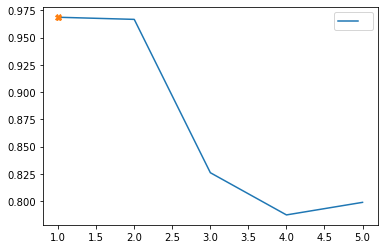

In [25]:
def show_results(cv, X_test, params, prefix=''):
    prefix = ' '+prefix    
    results = pd.DataFrame(cv.cv_results_)
    # Plot the CV (mean) scores for all possible parameters
    plt.plot(results[params],results['mean_test_score'], label=prefix)

    # Find the best
    best_idx =np.argmax(results['mean_test_score']) #Returns the indices of the maximum values along an axis.
    # Plot it as a cross
    plt.plot(results[params][best_idx],
             results['mean_test_score'][best_idx], marker='X')
    plt.legend()

    print(prefix, f"(best {results[params][best_idx]}) CV accuracy:",  cv.best_score_)
    print(prefix, f"(best {results[params][best_idx]}) Test accuracy:", accuracy(y_test, cv.best_estimator_.predict(X_test)))
    
show_results(cv, X_full_test, 'param_poly__degree')

1 is the best degree, but, as we can see in the graph, there's no much different from degree 2. So we can also use a parabola to create the boundary with good resutls

### QDA

We can also extend LDA qwith the Quadratic Discriminant Analysis, much more flexibile since it does not assume that each class shares the same covariance matrix. 

In [26]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
model = QDA(store_covariance = True)
model = model.fit(X_full_train, y_train)

print("Train accuracy:", accuracy(y_train, model.predict(X_full_train)))
print("Test accuracy:", accuracy(y_test, model.predict(X_full_test)))


Train accuracy: 0.958984375
Test accuracy: 0.9649122807017544


These are the best results until now.

## K-Nearest Neighbors

In [27]:
# Train a KNN with different k values
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_full_train, y_train)

print("Train accuracy:", accuracy(y_train, model.predict(X_full_train)))
print("Test accuracy:", accuracy(y_test, model.predict(X_full_test)))

Train accuracy: 1.0
Test accuracy: 0.9415204678362573


Best result unitl now. We can use the **hyperparameter selection** (gridsearch and cross-validation) to select the best K for the dataset.

In [28]:
from sklearn.model_selection import GridSearchCV

model = KNeighborsClassifier()
params = {'n_neighbors': range(1, 15)}
folds = 10
scorer = make_scorer(accuracy)

cv = GridSearchCV(model, params, cv = folds, scoring = scorer )
cv.fit(X_full_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 15)},
             scoring=make_scorer(accuracy))

  (best 5) CV accuracy: 0.9706636500754149
  (best 5) Test accuracy: 0.9473684210526315


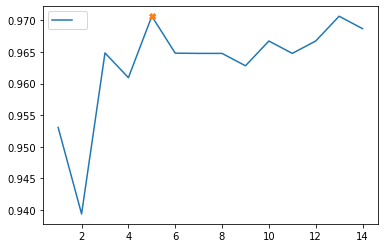

In [29]:
show_results(cv, X_full_test, "param_n_neighbors")

5 is the best K, and it returns the best result until now. Let's see if the it changes for normalization and standardization:

 Unnormalized (best 5) CV accuracy: 0.9706636500754149
 Unnormalized (best 5) Test accuracy: 0.9473684210526315
 StandardScaler (best 14) CV accuracy: 0.9706636500754149
 StandardScaler (best 14) Test accuracy: 0.9473684210526315
 MinMaxScaler (best 5) CV accuracy: 0.9706636500754149
 MinMaxScaler (best 5) Test accuracy: 0.9473684210526315


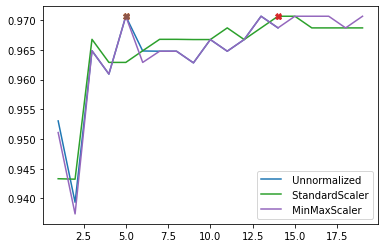

In [30]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

params = {'knn__n_neighbors': range(1, 20)}
model_std = Pipeline([
    ('norm', StandardScaler()),
    ('knn', KNeighborsClassifier())])
cv_std = GridSearchCV(model_std, params, refit=True, cv=10,
                     scoring=make_scorer(accuracy))
cv_std.fit(X_full_train, y_train)

model_minmax = Pipeline([
    ('norm', MinMaxScaler()),
    ('knn', KNeighborsClassifier())])
cv_minmax = GridSearchCV(model_minmax, params, refit=True, cv=10,
                        scoring=make_scorer(accuracy))
cv_minmax.fit(X_full_train, y_train)

# Plot the cv lines
show_results(cv, X_full_test, "param_n_neighbors", prefix="Unnormalized")
show_results(cv_std, X_full_test, 'param_knn__n_neighbors', "StandardScaler")
show_results(cv_minmax, X_full_test, 'param_knn__n_neighbors', "MinMaxScaler")

The results don't change much. Notice that only Standard Scaler differs in K but it has the same test results, so, indeed, K=5 is still the best choice (simpler too).

## Support vector machine

I will perform both cases: Linearly Separable and Not Linearly Separable and I will compare them with other linear algorithms (Logistic Regression and Perceptron)

### Linearly Separable

Let's see how SVM will perform. Let's explore outside the margin (high 'C' values) and inside the margin (low 'C' values)

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# We set a very high C value, i.e., virtually
# disabling regularization
model = SVC(kernel='linear', C=10000)
model.fit(X_full_train, y_train)

train_acc = accuracy_score(model.predict(X_full_train), y_train)
test_acc = accuracy_score(model.predict(X_full_test), y_test)

print("SVM train accuracy:", train_acc)
print("SVM test accuracy:", test_acc)

SVM train accuracy: 0.97265625
SVM test accuracy: 0.9532163742690059


In [32]:
model = SVC(kernel='linear', C=1)
model.fit(X_full_train, y_train)

train_acc = accuracy_score(model.predict(X_full_train), y_train)
test_acc = accuracy_score(model.predict(X_full_test), y_test)

print("SVM train accuracy:", train_acc)
print("SVM test accuracy:", test_acc)

SVM train accuracy: 0.97265625
SVM test accuracy: 0.9532163742690059


(? I don't know how to correctly interpret the fact that they have the same results. I expected different results)

Comparison with the other algorithms:

In [33]:
from sklearn.linear_model import LogisticRegression, Perceptron

# Train the SVM
svm_model = SVC(kernel='linear', C=10000)
svm_model.fit(X_full_train, y_train)

# Train a LogisticRegressor
lr_model = LogisticRegression()
lr_model.fit(X_full_train, y_train)

# Train a Perceptron classifier (try verbose=True)
pt_model = Perceptron()
pt_model.fit(X_full_train, y_train)

for m in [svm_model, lr_model, pt_model]:
    train_acc = accuracy_score(y_train, m.predict(X_full_train))
    test_acc = accuracy_score(y_test, m.predict(X_full_test))
    print("{} train score: {}".format(m.__class__.__name__, train_acc))
    print("{} test score: {}".format(m.__class__.__name__, test_acc))

SVC train score: 0.97265625
SVC test score: 0.9532163742690059
LogisticRegression train score: 0.97265625
LogisticRegression test score: 0.9532163742690059
Perceptron train score: 0.966796875
Perceptron test score: 0.9415204678362573


Logistic and SVC have the better results, perceptron (as expected) is the worst between them (still nice results!).

### Not Linearly Serapable Problem

Same workflow but now I create a new data frame to make to underline the not linearly separable problem (ns)

In [34]:
# Select new data for the not linearly separable problem
feats=['Clump_Thickness', 'Uniformity_of_Cell_Size', 'Uniformity_of_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']
X_ns = df_canc[feats].to_numpy()
y_ns = df_canc['Class'].to_numpy()


X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(X_ns, y_ns,
                                                    test_size=split_test_size, 
                                                    random_state=split_seed)


In [35]:
# Train a LogisticRegressor
lr_model = LogisticRegression(solver='lbfgs')
lr_model.fit(X_ns_train, y_ns_train)

# Train a Perceptron classifier (try verbose=True and n_iter_no_change=100)
pt_model = Perceptron()
pt_model.fit(X_ns_train, y_ns_train)

# Train an SVM classifier
svm_model = SVC(kernel='linear', C=1e3)
svm_model.fit(X_ns_train, y_ns_train)


for m in [svm_model, lr_model, pt_model]:
    train_acc = accuracy_score(y_ns_train, m.predict(X_ns_train))
    test_acc = accuracy_score(y_ns_test, m.predict(X_ns_test))
    print("{} train score: {}".format(m.__class__.__name__, train_acc))
    print("{} test score: {}".format(m.__class__.__name__, test_acc))

SVC train score: 0.97265625
SVC test score: 0.9532163742690059
LogisticRegression train score: 0.97265625
LogisticRegression test score: 0.9532163742690059
Perceptron train score: 0.966796875
Perceptron test score: 0.9415204678362573


Same results as before (maybe it's redundant but I wanted to check all options). Let's try to find the optimal kernel :

In [36]:
#Grid Search for the best Kernel
from sklearn.model_selection import GridSearchCV

# Polynomial
param_grid = {'C': np.linspace(0.001, 100, 5),
              'coef0': np.linspace(-10, 10, 5),
              'degree': [2, 3, 4]}
svm_poly = GridSearchCV(SVC(kernel='poly'), param_grid,
                        cv=5, scoring='accuracy', refit=True)
svm_poly.fit(X_ns_train, y_ns_train)

# RBF
param_grid = {'C': np.linspace(0.001, 100, 5),
              'gamma': np.linspace(0.001, 100, 5)}
rbf_poly = GridSearchCV(SVC(kernel='rbf'), param_grid, 
                        cv=5, scoring='accuracy', refit=True)
rbf_poly.fit(X_ns_train, y_ns_train)

# Sigmoid
param_grid = {'C': np.linspace(0.001, 100, 5),
              'gamma': np.linspace(0.001, 100, 5),
              'coef0': np.linspace(-10, 10, 5)}
sigm_poly = GridSearchCV(SVC(kernel='sigmoid'), param_grid, 
                         cv=5, scoring='accuracy', refit=True)
sigm_poly.fit(X_ns_train, y_ns_train)

GridSearchCV(cv=5, estimator=SVC(kernel='sigmoid'),
             param_grid={'C': array([1.000000e-03, 2.500075e+01, 5.000050e+01, 7.500025e+01,
       1.000000e+02]),
                         'coef0': array([-10.,  -5.,   0.,   5.,  10.]),
                         'gamma': array([1.000000e-03, 2.500075e+01, 5.000050e+01, 7.500025e+01,
       1.000000e+02])},
             scoring='accuracy')

In [37]:
for m in [svm_poly, rbf_poly, sigm_poly]:
    cv_score = m.best_score_
    m = m.best_estimator_
    print(m)
    train_acc = accuracy_score(y_ns_train, m.predict(X_ns_train))
    test_acc = accuracy_score(y_ns_test, m.predict(X_ns_test))
    print("cv score: {}".format(cv_score))
    print("train score: {}".format(train_acc))
    print("test score: {}\n".format(test_acc))

SVC(C=0.001, coef0=5.0, degree=4, kernel='poly')
cv score: 0.9687797449076718
train score: 0.9765625
test score: 0.9473684210526315

SVC(C=25.00075, gamma=0.001)
cv score: 0.9667999238530364
train score: 0.974609375
test score: 0.9473684210526315

SVC(C=100.0, gamma=0.001, kernel='sigmoid')
cv score: 0.968741671425852
train score: 0.970703125
test score: 0.9532163742690059



Best kernel is sigmoid, and it returns the same test results as Logistic or SVC of before.

## Classification metrics

In [38]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

cm = confusion_matrix(y_ns_test, svm_poly.predict(X_ns_test))
cm.shape

(2, 2)

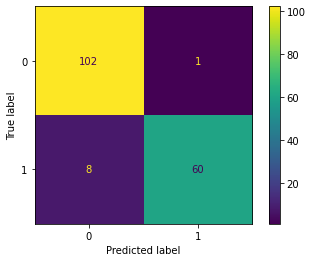

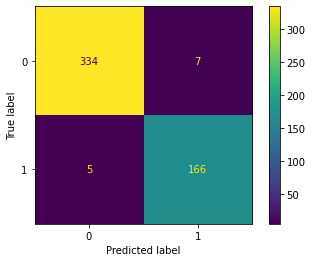

In [39]:
# Plot test confution matrix
plot_confusion_matrix(svm_poly, X_ns_test, y_ns_test)
# Plot train confution matrix
plot_confusion_matrix(svm_poly, X_ns_train, y_ns_train)

In [40]:
def sensitivity(cm):
    TP = cm[1,1]
    T = cm[1,:].sum()
    return TP / T

def specificity(cm):
    TN = cm[0,0]
    N = cm[0,:].sum()
    return TN / N

def precision(cm):
    TP = cm[1,1]
    TPFP = cm[:,1].sum()
    return TP / TPFP

def f1(cm):
    p = precision(cm)
    r = sensitivity(cm)
    return (2 * p * r) / (p + r)

print("Sensitivity ", sensitivity(cm))
print("Specificity ", specificity(cm))
print("Precision ", precision(cm))
print("F1-score", f1(cm))

Sensitivity  0.8823529411764706
Specificity  0.9902912621359223
Precision  0.9836065573770492
F1-score 0.9302325581395349


In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_ns_test, svm_poly.predict(X_ns_test), target_names=['benign', 'malignant']))

              precision    recall  f1-score   support

      benign       0.93      0.99      0.96       103
   malignant       0.98      0.88      0.93        68

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



Results are very very good since both are high, we're almost sure that, when we perform the test: <br>
• with high sensitivity we will flag almost everyone who has the disease (malignant cancer) and not generate many false-negative results (just x~12% of false positive people who have the disease and should have tested positive)    <br>
• with high-specificity will correctly rule out almost everyone who doesn’t have the disease (benign cancer) and won’t generate many false-positive results (less than 1 % of people who don’t have the disease and should have tested negative!) 

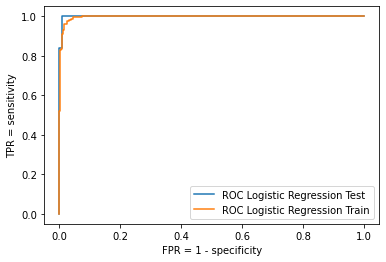

In [42]:
#ROC
from sklearn.metrics import roc_curve

def plot_roc(predict_fn, X, y, label=None):
    fprs, tprs, t = roc_curve(y, predict_fn(X)[:,-1])
    
    # Plot the ROC
    plt.plot(fprs, tprs, label="ROC "+label)
    plt.xlabel("FPR = 1 - specificity")
    plt.ylabel("TPR = sensitivity")
    plt.legend()
    
plot_roc(lr_model.predict_proba, X_ns_test, y_ns_test, "Logistic Regression Test")
plot_roc(lr_model.predict_proba, X_ns_train, y_ns_train, "Logistic Regression Train")

/Users/hastors/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


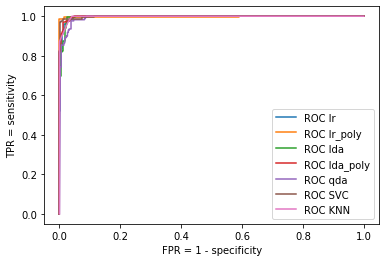

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

lr = LogisticRegression()
lr_poly = Pipeline([('poly', PolynomialFeatures(degree=2)),
                    ('lda', LogisticRegression())])

lda = LDA()
lda_poly = Pipeline([('poly', PolynomialFeatures(degree=2)),
                     ('lda', LDA())])
qda = QDA()

svc = SVC(C=75, degree=2, kernel='poly',  probability=True)

knn = KNeighborsClassifier(n_neighbors=3)

for name, model in [('lr', lr), 
                    ('lr_poly', lr_poly), 
                    ('lda', lda),
                    ('lda_poly', lda_poly), 
                    ('qda', qda),
                    ('SVC', svc),
                    ('KNN', knn)]:
    model.fit(X_ns_train, y_ns_train)
    plot_roc(model.predict_proba, X_ns_train, y_ns_train, name)

As we can see in the ROC plot all the models are pretty good, but the best one seems to be the **Logistic** (the orange one).   

# Conclusions 

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-0pky{border-color:inherit;text-align:left;vertical-align:top}
.tg .tg-fymr{border-color:inherit;font-weight:bold;text-align:left;vertical-align:top}
</style>
<table class="tg">
<thead>
  <tr>
    <th class="tg-0pky"></th>
    <th class="tg-0pky"><span style="font-weight:normal;font-style:normal">Multiple Logistic Regression</span></th>
    <th class="tg-0pky"><span style="font-weight:normal;font-style:normal">LDA</span></th>
    <th class="tg-0pky">PolyLDA</th>
    <th class="tg-0pky">CV_LDA (1)</th>
    <th class="tg-0pky">QDA</th>
    <th class="tg-0pky"><span style="font-weight:normal;font-style:normal">KNN</span></th>
    <th class="tg-0pky"><span style="font-weight:normal;font-style:normal">KNN-CV (5)</span></th>
    <th class="tg-0pky">SSMm</th>
    <th class="tg-0pky"><span style="font-weight:normal;font-style:normal">SVM</span></th>
  </tr>
</thead>
<tbody>
  <tr>
    <td class="tg-0pky">Train</td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.97265625</span></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9765625</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9687405731523379</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.958984375</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">1.0</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9706636500754149</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9706636500754149</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.97265625</span></td>
  </tr>
  <tr>
    <td class="tg-0pky">Test</td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9532163742690059</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.935672514619883</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9473684210526315</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.935672514619883</span></td>
    <td class="tg-fymr"><span style="font-weight:bold;font-style:normal">0.9649122807017544</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9415204678362573</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9473684210526315</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9473684210526315</span></td>
    <td class="tg-0pky"><span style="font-weight:normal;font-style:normal">0.9532163742690059</span></td>
  </tr>
  <tr>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
    <td class="tg-0pky"></td>
  </tr>
</tbody>
</table>

We analyzed and understood different factors to classify if the tumor is benign or malignant. We approached this problem using different algorithms and experimented with various hyperparameter to improve model accuracy. <br>In the end we found out that QDA has the best performance among them but, as we can see here in the table, there is no model that doesn't perform very well. ROC also suggest that Logistic may have the best performance. <br> Another discriminant (that I did not use) could be the performance of every test in terms of specifity and sensitivy but, got this far, I can safely say that we can use every model (used in this notebook) to have nice results in classification.